# Notebook 01 – Logistic Model Fitting

## Introduction

This notebook develops and calibrates a classical logistic growth model for China’s population using historical data from 1950 to 2023.

We model population dynamics using the nonlinear differential equation

$$\frac{dP}{dt} = rP\left(1 - \frac{P}{K}\right)$$

Where:

- $P\left(t\right)$ = population (billions)
- $r$ = intrinsic growth rate  
- $K$ = carrying capacity  
- $A$ = integration constant 

The objectives of this notebook are:

1. To estimate the parameters $r$ and $K$ via nonlinear least squares regression.
2. To compare the fitted model with observed population data.
3. To evaluate model performance through residual analysis.

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [17]:
data = pd.read_csv("china_pop_1950_2023_UN.csv")

In [18]:
t = data["year"] - data["year"].min()
P = data["population"]

In [19]:
def logistic(t, K, r, A):
    return K / (1 + A * np.exp(-r * t))

In [20]:
#Population values were rescaled to billions to improve numerical conditioning during parameter estimation.
P = data["population"] / 1e9

In [25]:
initial_guess = [1.6, 0.03, 10]
params, covariance = curve_fit(logistic, t, P, p0=initial_guess, maxfev=10000)
K_est, r_est, A_est = params

In [34]:
print("Estimated K:", K_est)
print("Estimated r:", r_est)
print("Estimated A:", A_est)

Estimated K: 1.5988153493907211
Estimated r: 0.0412444953186689
Estimated A: 2.1547780229781694


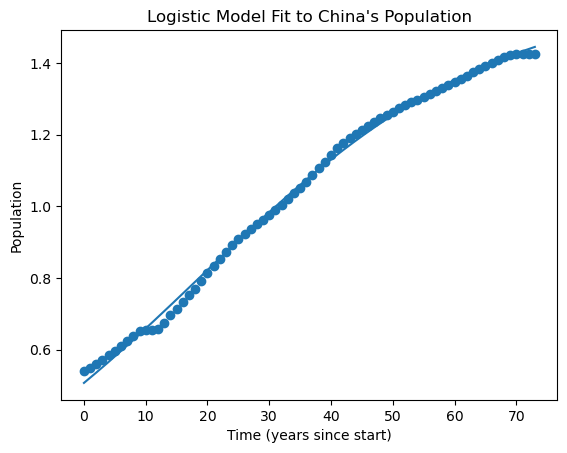

In [35]:
t_fit = np.linspace(t.min(), t.max(), 300)
P_fit = logistic(t_fit, K_est, r_est, A_est)

plt.figure()
plt.scatter(t, P)
plt.plot(t_fit, P_fit)
plt.xlabel("Time (years since start)")
plt.ylabel("Population")
plt.title("Logistic Model Fit to China's Population")
plt.show()

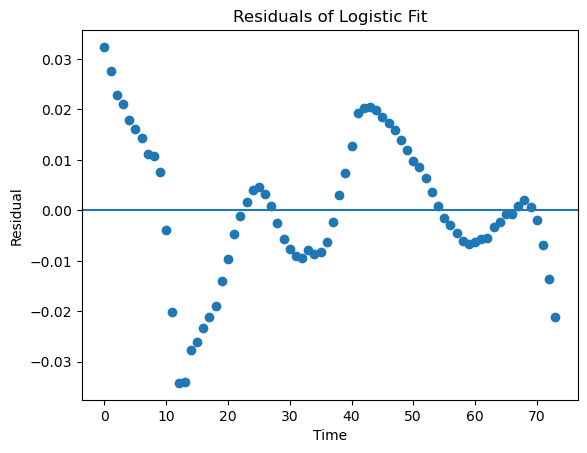

In [36]:
residuals = P - logistic(t, K_est, r_est, A_est)

plt.figure()
plt.scatter(t, residuals)
plt.axhline(0)
plt.xlabel("Time")
plt.ylabel("Residual")
plt.title("Residuals of Logistic Fit")
plt.show()

In [37]:
rss = np.sum(residuals**2)
print("Residual Sum of Squares:", rss)

Residual Sum of Squares: 0.014515015164182342


In [38]:
ss_total = np.sum((P - np.mean(P))**2)
r_squared = 1 - rss/ss_total
print("R^2:", r_squared)

R^2: 0.9976479015592699


## DISCUSSION

The fitted logistic model yields an estimated carrying capacity

$𝐾 = 1.60$ billion


This suggests that, under the assumptions of the classical logistic framework, China’s long-term population would stabilize near 1.6 billion. Given that the observed peak population was approximately 1.41–1.42 billion, the model predicts additional growth before asymptotic stabilization. However, recent empirical decline suggests that this estimated carrying capacity may reflect historical growth dynamics rather than future demographic realities.

The intrinsic growth rate is estimated as 

$r = 0.041$

indicating that during the early growth phase, the population increased at approximately 4% annually under the model’s assumptions. This is consistent with post-1950 expansion, when improvements in public health and economic development contributed to sustained population growth.

The parameter $A$ governs the horizontal shift of the curve and is determined by the initial population level relative to the carrying capacity. Its estimated value ensures consistency with the 1950 baseline data.

### Model Fit and Limitations

While the logistic model captures the overall sigmoidal growth pattern from 1950 through the early 2000s, residual analysis indicates systematic deviation in recent years. In particular, the model does not naturally accommodate sustained population decline once saturation is reached, as the classical logistic equation assumes a constant carrying capacity and positive intrinsic growth rate.

This suggests that demographic transitions, policy changes, and socio-economic factors may effectively alter model parameters over time. Consequently, the logistic framework provides a useful first-order approximation but may require modification to fully describe modern population reversal dynamics.